# V2 하락장 대응 자동매매 백테스트

2024-01-01부터 실행 시점까지 업비트 OHLCV를 받아서 하락장 대응 전략 후보를 비교합니다.

핵심 비교 대상:
- `buy_and_hold`: 비트코인 현물 보유 기준선
- `v1_rsi_rebound_long`: v1 RSI 반등 아이디어를 단일 포지션 백테스트로 단순화
- `bear_rsi_scalp_long`: 하락장 안에서 과매도 반등만 짧게 먹는 현물 전략
- `cash_guard_breakout_long`: 하락장에는 현금을 들고, 상승 추세 복귀 때만 진입하는 방어형 현물 전략
- `synthetic_short_breakdown`: 하락 추세 붕괴 구간에서 숏을 잡는 가상 전략
- `bear_ema_reject_short`: 하락장 반등이 EMA20에서 막힐 때 숏을 잡는 가상 전략
- `bear_atr_trailing_short`: 하락 추세 숏 진입 후 ATR 기반 시간/반등 청산을 쓰는 가상 전략
- `panic_reversal_long`: 급락 이후 RSI 회복만 짧게 먹는 현물 반등 전략
- `range_reversion_long`: 큰 추세가 없는 구간에서 밴드 하단 회귀를 노리는 현물 전략
- `spot_defensive_combo`: 업비트 현물만 쓸 때를 위한 급락 반등/박스권 회귀/상승 돌파 조합
- `spot_cash_guard_optimized`: 현물 전용 최적화에서 나온 RSI50/VOL1.2/SL4 방어형 돌파 후보
- `spot_cash_guard_robust`: 워크포워드 최악 구간도 플러스였던 RSI50/VOL1.5/SL3/EMA20 현물 후보
- `bear_spot_quick_rebound`: 하락장에서 RSI24 과매도 반등을 4봉 이내로 짧게 먹는 현물 단타 후보
- `v2_bear_hybrid`: 하락장에서는 숏, 상승장에서는 돌파 롱을 쓰는 하이브리드 후보
- `v2_bear_hybrid_optimized`: 첫 최적화에서 나온 RSI46/TP9/SL3/28봉 숏 규칙을 고정한 후보
- `v2_bear_hybrid_v2`: EMA 저항 숏, 급락 반등 롱, 상승 돌파 롱을 섞은 확장 후보

주의: 업비트 현물은 숏 포지션을 직접 지원하지 않습니다. `synthetic_short_breakdown`, `bear_ema_reject_short`, `bear_atr_trailing_short`, `v2_bear_hybrid`, `v2_bear_hybrid_v2`의 숏 구간은 선물/마진/인버스 상품을 쓸 때의 전략 후보를 검증하기 위한 가상 백테스트입니다.


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime
import time
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyupbit

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format


In [3]:
# ===== 실행 파라미터 =====
TICKERS = ["KRW-BTC"]  # 비교할 종목을 늘리고 싶으면 ["KRW-BTC", "KRW-ETH", "KRW-SOL"]처럼 추가
INTERVAL = "minute240"
START_DATE = "2024-01-01"
WARMUP_START = "2023-07-01"  # EMA200, RSI, ATR 워밍업용
END_DATE = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
INITIAL_CAPITAL = 1_000_000
FEE_RATE = 0.0005  # 업비트 기본 수수료 0.05% 가정
API_PAUSE_SECONDS = 0.12

print(f"backtest window: {START_DATE} ~ {END_DATE}")


backtest window: 2024-01-01 ~ 2026-05-28 23:12:50


In [4]:
def fetch_ohlcv_history(
    ticker: str,
    interval: str,
    start: str,
    end: str | None = None,
    pause_seconds: float = 0.12,
    max_batches: int = 200,
) -> pd.DataFrame:
    """pyupbit의 200개 제한을 피해서 start~end 구간 OHLCV를 뒤로 넘겨 받습니다."""

    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end) if end else pd.Timestamp.now()
    to = end_ts
    frames: list[pd.DataFrame] = []

    for _ in range(max_batches):
        df = pyupbit.get_ohlcv(
            ticker,
            interval=interval,
            count=200,
            to=to.strftime("%Y-%m-%d %H:%M:%S"),
            period=pause_seconds,
        )
        if df is None or df.empty:
            break

        frames.append(df)
        oldest = pd.Timestamp(df.index.min())
        if oldest <= start_ts:
            break

        to = oldest - pd.Timedelta(seconds=1)
        time.sleep(pause_seconds)

    if not frames:
        raise ValueError(f"no OHLCV data: {ticker} {interval}")

    result = pd.concat(frames).sort_index()
    result = result[~result.index.duplicated(keep="first")]
    result = result[(result.index >= start_ts) & (result.index <= end_ts)]
    if result.empty:
        raise ValueError(f"empty OHLCV after filtering: {ticker} {interval}")
    return result


def rsi(close: pd.Series, period: int = 14) -> pd.Series:
    delta = close.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    avg_up = up.ewm(com=period - 1, min_periods=period).mean()
    avg_down = down.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_up / avg_down
    return 100 - (100 / (1 + rs))


def atr(df: pd.DataFrame, period: int = 14) -> pd.Series:
    prev_close = df["close"].shift(1)
    true_range = pd.concat(
        [
            df["high"] - df["low"],
            (df["high"] - prev_close).abs(),
            (df["low"] - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    return true_range.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()


def add_indicators(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy()
    for period in [10, 20, 50, 120, 200]:
        df[f"ema{period}"] = df["close"].ewm(span=period, adjust=False).mean()

    df["rsi14"] = rsi(df["close"], 14)
    df["atr14"] = atr(df, 14)
    df["atr_pct"] = df["atr14"] / df["close"] * 100
    df["high20_prev"] = df["high"].rolling(20).max().shift(1)
    df["low20_prev"] = df["low"].rolling(20).min().shift(1)
    df["low10_prev"] = df["low"].rolling(10).min().shift(1)
    df["volume_ratio"] = df["volume"] / df["volume"].rolling(20).mean().shift(1)
    df["ret_12"] = df["close"].pct_change(12)
    df["bear_regime"] = (df["close"] < df["ema200"]) & (df["ema50"] < df["ema200"])
    df["bull_regime"] = (df["close"] > df["ema200"]) & (df["ema50"] > df["ema200"])
    df["panic_drop"] = df["ret_12"] <= -0.08
    return df.dropna().copy()


In [5]:
@dataclass(frozen=True)
class Strategy:
    name: str
    allocation: float
    entry_func: Callable[[pd.Series, pd.Series], int]
    exit_func: Callable[[pd.Series, float, int, int], bool]
    description: str


@dataclass(frozen=True)
class Trade:
    ticker: str
    strategy: str
    side: str
    entry_time: pd.Timestamp
    exit_time: pd.Timestamp
    entry_price: float
    exit_price: float
    return_pct: float
    equity_after: float
    bars_held: int


@dataclass(frozen=True)
class BacktestResult:
    ticker: str
    strategy: str
    final_equity: float
    total_return_pct: float
    max_drawdown_pct: float
    trade_count: int
    win_rate_pct: float
    profit_factor: float
    exposure_pct: float
    trades: pd.DataFrame
    equity_curve: pd.Series


def strategy_buy_and_hold_entry(row: pd.Series, prev: pd.Series) -> int:
    return 1


def strategy_buy_and_hold_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    return False


def strategy_v1_rsi_entry(row: pd.Series, prev: pd.Series) -> int:
    if prev["rsi14"] <= 30 and row["rsi14"] > 30:
        return 1
    return 0


def strategy_v1_rsi_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    return (row["rsi14"] >= 70 and revenue_pct >= 1.0) or revenue_pct <= -10.0 or bars_held >= 60


def strategy_bear_rsi_scalp_entry(row: pd.Series, prev: pd.Series) -> int:
    oversold_turn = prev["rsi14"] <= 28 and row["rsi14"] > prev["rsi14"]
    volatility_ok = row["atr_pct"] >= 1.0
    return 1 if row["bear_regime"] and oversold_turn and volatility_ok else 0


def strategy_bear_rsi_scalp_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    atr_stop_pct = max(2.2, row["atr_pct"] * 1.2)
    return revenue_pct >= 3.0 or revenue_pct <= -atr_stop_pct or bars_held >= 8 or row["close"] < row["low10_prev"]


def strategy_cash_guard_entry(row: pd.Series, prev: pd.Series) -> int:
    breakout = row["close"] > row["high20_prev"]
    volume_confirmed = row["volume_ratio"] >= 1.2
    return 1 if row["bull_regime"] and breakout and volume_confirmed and row["rsi14"] >= 52 else 0


def strategy_cash_guard_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    return row["close"] < row["ema50"] or revenue_pct <= -5.0 or (row["rsi14"] >= 75 and revenue_pct >= 4.0)


def strategy_short_breakdown_entry(row: pd.Series, prev: pd.Series) -> int:
    breakdown = row["close"] < row["low20_prev"]
    momentum_down = row["ema10"] < row["ema20"] and row["rsi14"] < 45
    volume_or_panic = row["volume_ratio"] >= 1.1 or row["panic_drop"]
    return -1 if row["bear_regime"] and breakdown and momentum_down and volume_or_panic else 0


def strategy_short_breakdown_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (entry_price / row["close"] - 1) * 100
    return revenue_pct >= 8.0 or revenue_pct <= -4.0 or row["close"] > row["ema20"] or bars_held >= 24


def strategy_bear_ema_reject_entry(row: pd.Series, prev: pd.Series) -> int:
    touched_resistance = row["high"] >= row["ema20"] * 0.995
    rejected = row["close"] < row["ema20"] and row["close"] < row["open"]
    momentum_fading = row["rsi14"] < 55 and row["rsi14"] < prev["rsi14"]
    trend_down = row["ema10"] < row["ema20"] < row["ema50"]
    return -1 if row["bear_regime"] and touched_resistance and rejected and momentum_fading and trend_down else 0


def strategy_bear_ema_reject_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (entry_price / row["close"] - 1) * 100
    stop_pct = max(3.2, row["atr_pct"] * 1.4)
    return revenue_pct >= 5.5 or revenue_pct <= -stop_pct or row["close"] > row["ema50"] or bars_held >= 18


def strategy_bear_atr_trailing_entry(row: pd.Series, prev: pd.Series) -> int:
    trend_down = row["bear_regime"] and row["ema10"] < row["ema20"] < row["ema50"]
    fresh_low = row["close"] < row["low20_prev"]
    volatility_ok = 1.0 <= row["atr_pct"] <= 7.5
    return -1 if trend_down and fresh_low and volatility_ok and row["rsi14"] < 42 else 0


def strategy_bear_atr_trailing_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (entry_price / row["close"] - 1) * 100
    giveback_or_reversal = row["close"] > row["ema10"] and row["rsi14"] > 48
    return revenue_pct >= max(6.0, row["atr_pct"] * 2.0) or revenue_pct <= -3.5 or giveback_or_reversal or bars_held >= 20


def strategy_panic_reversal_entry(row: pd.Series, prev: pd.Series) -> int:
    washed_out = row["panic_drop"] or prev["rsi14"] <= 24
    reversal = row["rsi14"] > prev["rsi14"] and row["close"] > row["open"]
    still_discounted = row["close"] < row["ema50"]
    return 1 if washed_out and reversal and still_discounted and row["atr_pct"] >= 1.2 else 0


def strategy_panic_reversal_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    stop_pct = max(2.5, row["atr_pct"] * 1.1)
    return revenue_pct >= 4.0 or revenue_pct <= -stop_pct or row["rsi14"] >= 50 or bars_held >= 6


def strategy_range_reversion_entry(row: pd.Series, prev: pd.Series) -> int:
    neutral_regime = not bool(row["bear_regime"]) and not bool(row["bull_regime"])
    lower_band = row["ema50"] - row["atr14"] * 1.2
    stretched_down = row["close"] < lower_band and row["rsi14"] < 38
    turn = row["close"] > row["open"] or row["rsi14"] > prev["rsi14"]
    return 1 if neutral_regime and stretched_down and turn else 0


def strategy_range_reversion_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    return row["close"] >= row["ema50"] or revenue_pct >= 3.5 or revenue_pct <= -3.0 or bars_held >= 12


def strategy_spot_defensive_combo_entry(row: pd.Series, prev: pd.Series) -> int:
    for entry_func in [
        strategy_panic_reversal_entry,
        strategy_range_reversion_entry,
        strategy_cash_guard_entry,
    ]:
        signal = entry_func(row, prev)
        if signal == 1:
            return 1
    return 0


def strategy_spot_defensive_combo_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    if row["bear_regime"]:
        return revenue_pct >= 4.0 or revenue_pct <= -3.0 or row["rsi14"] >= 52 or bars_held >= 8
    if row["bull_regime"]:
        return row["close"] < row["ema50"] or revenue_pct <= -5.0 or (row["rsi14"] >= 75 and revenue_pct >= 4.0)
    return row["close"] >= row["ema50"] or revenue_pct >= 3.5 or revenue_pct <= -3.0 or bars_held >= 12


def strategy_spot_cash_guard_optimized_entry(row: pd.Series, prev: pd.Series) -> int:
    breakout = row["close"] > row["high20_prev"]
    volume_confirmed = row["volume_ratio"] >= 1.2
    return 1 if row["bull_regime"] and breakout and volume_confirmed and row["rsi14"] >= 50 else 0


def strategy_spot_cash_guard_optimized_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    return row["close"] < row["ema50"] or revenue_pct <= -4.0 or (row["rsi14"] >= 75 and revenue_pct >= 4.0)


def strategy_spot_cash_guard_robust_entry(row: pd.Series, prev: pd.Series) -> int:
    breakout = row["close"] > row["high20_prev"]
    volume_confirmed = row["volume_ratio"] >= 1.5
    return 1 if row["bull_regime"] and breakout and volume_confirmed and row["rsi14"] >= 50 else 0


def strategy_spot_cash_guard_robust_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    return row["close"] < row["ema20"] or revenue_pct <= -3.0 or (row["rsi14"] >= 72 and revenue_pct >= 3.0)


def strategy_bear_spot_quick_rebound_entry(row: pd.Series, prev: pd.Series) -> int:
    rsi_turn = prev["rsi14"] <= 24 and row["rsi14"] > prev["rsi14"]
    strong_green = row["close"] > row["open"] and row["close"] > prev["close"]
    volume_ok = row["volume_ratio"] >= 1.0
    return 1 if row["bear_regime"] and rsi_turn and strong_green and volume_ok else 0


def strategy_bear_spot_quick_rebound_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (row["close"] / entry_price - 1) * 100
    return revenue_pct >= 1.5 or revenue_pct <= -2.5 or row["rsi14"] >= 48 or bars_held >= 4


def strategy_hybrid_v2_entry(row: pd.Series, prev: pd.Series) -> int:
    for entry_func in [
        strategy_bear_ema_reject_entry,
        strategy_bear_atr_trailing_entry,
        strategy_panic_reversal_entry,
        strategy_cash_guard_entry,
    ]:
        signal = entry_func(row, prev)
        if signal:
            return signal
    return 0


def strategy_hybrid_v2_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    if side == -1:
        short_revenue = (entry_price / row["close"] - 1) * 100
        return short_revenue >= 6.5 or short_revenue <= -3.8 or (row["close"] > row["ema20"] and row["rsi14"] > 50) or bars_held >= 20
    long_revenue = (row["close"] / entry_price - 1) * 100
    return long_revenue >= 4.0 or long_revenue <= -3.2 or row["close"] < row["ema20"] or bars_held >= 18


def strategy_hybrid_entry(row: pd.Series, prev: pd.Series) -> int:
    short_signal = strategy_short_breakdown_entry(row, prev)
    if short_signal:
        return short_signal
    return strategy_cash_guard_entry(row, prev)


def strategy_hybrid_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    if side == -1:
        return strategy_short_breakdown_exit(row, entry_price, bars_held, side)
    return strategy_cash_guard_exit(row, entry_price, bars_held, side)


def strategy_short_breakdown_opt_entry(row: pd.Series, prev: pd.Series) -> int:
    breakdown = row["close"] < row["low20_prev"]
    momentum_down = row["ema10"] < row["ema20"] and row["rsi14"] < 46
    return -1 if row["bear_regime"] and breakdown and momentum_down else 0


def strategy_short_breakdown_opt_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    revenue_pct = (entry_price / row["close"] - 1) * 100
    return revenue_pct >= 9.0 or revenue_pct <= -3.0 or row["close"] > row["ema20"] or bars_held >= 28


def strategy_hybrid_optimized_entry(row: pd.Series, prev: pd.Series) -> int:
    short_signal = strategy_short_breakdown_opt_entry(row, prev)
    if short_signal:
        return short_signal
    return strategy_cash_guard_entry(row, prev)


def strategy_hybrid_optimized_exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
    if side == -1:
        return strategy_short_breakdown_opt_exit(row, entry_price, bars_held, side)
    return strategy_cash_guard_exit(row, entry_price, bars_held, side)


STRATEGIES = [
    Strategy("buy_and_hold", 1.00, strategy_buy_and_hold_entry, strategy_buy_and_hold_exit, "현물 단순 보유 기준선"),
    Strategy("v1_rsi_rebound_long", 0.35, strategy_v1_rsi_entry, strategy_v1_rsi_exit, "v1 RSI 반등 아이디어 단순화"),
    Strategy("bear_rsi_scalp_long", 0.35, strategy_bear_rsi_scalp_entry, strategy_bear_rsi_scalp_exit, "하락장 과매도 반등만 짧게 매수"),
    Strategy("cash_guard_breakout_long", 0.70, strategy_cash_guard_entry, strategy_cash_guard_exit, "하락장은 현금, 상승장 돌파만 매수"),
    Strategy("synthetic_short_breakdown", 0.70, strategy_short_breakdown_entry, strategy_short_breakdown_exit, "가상 숏: 하락 추세 붕괴 추종"),
    Strategy("bear_ema_reject_short", 0.70, strategy_bear_ema_reject_entry, strategy_bear_ema_reject_exit, "가상 숏: 하락장 EMA20 저항 실패"),
    Strategy("bear_atr_trailing_short", 0.70, strategy_bear_atr_trailing_entry, strategy_bear_atr_trailing_exit, "가상 숏: ATR 기반 하락 추세 추종"),
    Strategy("panic_reversal_long", 0.35, strategy_panic_reversal_entry, strategy_panic_reversal_exit, "현물: 급락 후 짧은 되돌림"),
    Strategy("range_reversion_long", 0.35, strategy_range_reversion_entry, strategy_range_reversion_exit, "현물: 박스권 하단 평균회귀"),
    Strategy("spot_defensive_combo", 0.45, strategy_spot_defensive_combo_entry, strategy_spot_defensive_combo_exit, "현물 전용: 급락 반등 + 박스권 회귀 + 상승 돌파"),
    Strategy("spot_cash_guard_optimized", 0.90, strategy_spot_cash_guard_optimized_entry, strategy_spot_cash_guard_optimized_exit, "현물 전용 최적화 후보: RSI50 VOL1.2 SL4"),
    Strategy("spot_cash_guard_robust", 0.90, strategy_spot_cash_guard_robust_entry, strategy_spot_cash_guard_robust_exit, "현물 전용 robust 후보: RSI50 VOL1.5 SL3 EMA20"),
    Strategy("bear_spot_quick_rebound", 0.50, strategy_bear_spot_quick_rebound_entry, strategy_bear_spot_quick_rebound_exit, "현물 하락장 단타: RSI24 반등 + 4봉 이내 청산"),
    Strategy("v2_bear_hybrid", 0.70, strategy_hybrid_entry, strategy_hybrid_exit, "하락장 숏 + 상승장 돌파 롱 하이브리드"),
    Strategy("v2_bear_hybrid_optimized", 0.70, strategy_hybrid_optimized_entry, strategy_hybrid_optimized_exit, "최적화 후보 고정: RSI46 TP9 SL3 28봉 숏 + 상승 돌파 롱"),
    Strategy("v2_bear_hybrid_v2", 0.70, strategy_hybrid_v2_entry, strategy_hybrid_v2_exit, "EMA 저항 숏 + 급락 반등 롱 + 상승 돌파 롱"),
]


In [6]:
def compute_max_drawdown_pct(equity: pd.Series) -> float:
    peak = equity.cummax()
    drawdown = (equity / peak - 1) * 100
    return float(drawdown.min()) if len(drawdown) else 0.0


def summarize_trades(trades: pd.DataFrame) -> tuple[float, float]:
    if trades.empty:
        return 0.0, 0.0
    wins = trades[trades["return_pct"] > 0]
    losses = trades[trades["return_pct"] <= 0]
    win_rate = len(wins) / len(trades) * 100
    gross_profit = wins["return_pct"].sum()
    gross_loss = abs(losses["return_pct"].sum())
    profit_factor = float("inf") if gross_loss == 0 and gross_profit > 0 else (gross_profit / gross_loss if gross_loss else 0.0)
    return win_rate, profit_factor


def run_backtest(
    ticker: str,
    df: pd.DataFrame,
    strategy: Strategy,
    initial_capital: float = INITIAL_CAPITAL,
    fee_rate: float = FEE_RATE,
) -> BacktestResult:
    equity = float(initial_capital)
    base_equity = equity
    position_side = 0
    entry_price = 0.0
    entry_time: pd.Timestamp | None = None
    entry_index = 0
    notional = 0.0
    trades: list[Trade] = []
    equity_points: list[tuple[pd.Timestamp, float]] = []
    exposed_bars = 0

    rows = list(df.iterrows())
    for i in range(1, len(rows) - 1):
        current_time, row = rows[i]
        _, prev = rows[i - 1]
        next_time, next_row = rows[i + 1]

        mark_equity = equity
        if position_side != 0:
            exposed_bars += 1
            pct_change = float(row["close"] / entry_price - 1)
            mark_equity = base_equity + position_side * notional * pct_change
            bars_held = i - entry_index
            if strategy.exit_func(row, entry_price, bars_held, position_side):
                exit_price = float(next_row["open"])
                exit_value_ratio = exit_price / entry_price
                pnl = position_side * notional * (exit_value_ratio - 1)
                exit_fee = notional * exit_value_ratio * fee_rate
                equity = base_equity + pnl - exit_fee
                trade_return_pct = (equity / (base_equity + notional * fee_rate) - 1) * 100
                trades.append(
                    Trade(
                        ticker=ticker,
                        strategy=strategy.name,
                        side="long" if position_side == 1 else "short",
                        entry_time=entry_time,
                        exit_time=next_time,
                        entry_price=entry_price,
                        exit_price=exit_price,
                        return_pct=trade_return_pct,
                        equity_after=equity,
                        bars_held=bars_held,
                    )
                )
                base_equity = equity
                position_side = 0
                entry_price = 0.0
                entry_time = None
                notional = 0.0
                mark_equity = equity

        if position_side == 0:
            signal_side = strategy.entry_func(row, prev)
            if signal_side != 0:
                entry_price = float(next_row["open"])
                entry_time = next_time
                position_side = int(signal_side)
                entry_index = i + 1
                notional = equity * strategy.allocation
                entry_fee = notional * fee_rate
                base_equity = equity - entry_fee
                mark_equity = base_equity

        equity_points.append((current_time, mark_equity))

    if position_side != 0 and entry_time is not None:
        final_time = df.index[-1]
        final_price = float(df["close"].iloc[-1])
        exit_value_ratio = final_price / entry_price
        pnl = position_side * notional * (exit_value_ratio - 1)
        exit_fee = notional * exit_value_ratio * fee_rate
        equity = base_equity + pnl - exit_fee
        trade_return_pct = (equity / (base_equity + notional * fee_rate) - 1) * 100
        trades.append(
            Trade(
                ticker=ticker,
                strategy=strategy.name,
                side="long" if position_side == 1 else "short",
                entry_time=entry_time,
                exit_time=final_time,
                entry_price=entry_price,
                exit_price=final_price,
                return_pct=trade_return_pct,
                equity_after=equity,
                bars_held=len(df) - 1 - entry_index,
            )
        )
        equity_points.append((final_time, equity))

    equity_curve = pd.Series(
        [point[1] for point in equity_points],
        index=[point[0] for point in equity_points],
        name=strategy.name,
    )
    if equity_curve.empty:
        equity_curve = pd.Series([initial_capital], index=[df.index[0]], name=strategy.name)

    trades_df = pd.DataFrame([trade.__dict__ for trade in trades])
    win_rate, profit_factor = summarize_trades(trades_df)
    final_equity = float(equity_curve.iloc[-1])
    return BacktestResult(
        ticker=ticker,
        strategy=strategy.name,
        final_equity=final_equity,
        total_return_pct=(final_equity / initial_capital - 1) * 100,
        max_drawdown_pct=compute_max_drawdown_pct(equity_curve),
        trade_count=len(trades_df),
        win_rate_pct=win_rate,
        profit_factor=profit_factor,
        exposure_pct=exposed_bars / max(len(df), 1) * 100,
        trades=trades_df,
        equity_curve=equity_curve,
    )


In [7]:
# ===== 데이터 수집 및 백테스트 실행 =====
all_results: list[BacktestResult] = []
prepared_data: dict[str, pd.DataFrame] = {}

for ticker in TICKERS:
    print(f"fetching {ticker}...")
    raw = fetch_ohlcv_history(
        ticker=ticker,
        interval=INTERVAL,
        start=WARMUP_START,
        end=END_DATE,
        pause_seconds=API_PAUSE_SECONDS,
    )
    prepared = add_indicators(raw)
    prepared = prepared[prepared.index >= pd.Timestamp(START_DATE)].copy()
    prepared_data[ticker] = prepared

    print(f"{ticker}: {prepared.index.min()} ~ {prepared.index.max()}, rows={len(prepared):,}")
    for strategy in STRATEGIES:
        all_results.append(run_backtest(ticker, prepared, strategy))

summary = pd.DataFrame(
    [
        {
            "ticker": result.ticker,
            "strategy": result.strategy,
            "final_equity": result.final_equity,
            "total_return_pct": result.total_return_pct,
            "max_drawdown_pct": result.max_drawdown_pct,
            "trade_count": result.trade_count,
            "win_rate_pct": result.win_rate_pct,
            "profit_factor": result.profit_factor,
            "exposure_pct": result.exposure_pct,
        }
        for result in all_results
    ]
).sort_values(["ticker", "total_return_pct"], ascending=[True, False])

summary


fetching KRW-BTC...
KRW-BTC: 2024-01-01 01:00:00 ~ 2026-05-28 21:00:00, rows=5,274


,ticker,strategy,final_equity,total_return_pct,max_drawdown_pct,trade_count,win_rate_pct,profit_factor,exposure_pct
5,KRW-BTC,v2_bear_hybrid,"1,932,276.39",93.23,-16.47,113,51.33,1.69,37.77
0,KRW-BTC,buy_and_hold,"1,881,037.51",88.10,-48.09,1,100.00,inf,99.94
3,KRW-BTC,cash_guard_breakout_long,"1,506,539.94",50.65,-17.96,67,52.24,1.76,26.55
4,KRW-BTC,synthetic_short_breakdown,"1,282,592.21",28.26,-11.01,46,50.00,1.61,11.22
2,KRW-BTC,bear_rsi_scalp_long,"996,425.21",-0.36,-5.18,36,52.78,0.99,3.58
1,KRW-BTC,v1_rsi_rebound_long,"892,761.90",-10.72,-18.64,38,52.63,0.77,37.73


In [8]:
# 하락장 대응 목적의 기본 랭킹: 수익률은 높고 MDD와 노출 시간은 낮은 전략을 우선합니다.
ranked = summary.copy()
ranked["score"] = (
    ranked["total_return_pct"]
    - ranked["max_drawdown_pct"].abs() * 0.8
    - ranked["exposure_pct"] * 0.05
)
ranked.sort_values(["ticker", "score"], ascending=[True, False])


,ticker,strategy,final_equity,total_return_pct,max_drawdown_pct,trade_count,win_rate_pct,profit_factor,exposure_pct,score
5,KRW-BTC,v2_bear_hybrid,"1,932,276.39",93.23,-16.47,113,51.33,1.69,37.77,78.16
0,KRW-BTC,buy_and_hold,"1,881,037.51",88.10,-48.09,1,100.00,inf,99.94,44.64
3,KRW-BTC,cash_guard_breakout_long,"1,506,539.94",50.65,-17.96,67,52.24,1.76,26.55,34.96
4,KRW-BTC,synthetic_short_breakdown,"1,282,592.21",28.26,-11.01,46,50.00,1.61,11.22,18.89
2,KRW-BTC,bear_rsi_scalp_long,"996,425.21",-0.36,-5.18,36,52.78,0.99,3.58,-4.68
1,KRW-BTC,v1_rsi_rebound_long,"892,761.90",-10.72,-18.64,38,52.63,0.77,37.73,-27.52


In [ ]:
# ===== 파라미터 탐색: 하락장용 숏/하이브리드 후보를 자동으로 조금 더 찾아봅니다. =====
def make_param_short_breakdown_strategy(
    rsi_max: float,
    profit_target_pct: float,
    stop_loss_pct: float,
    max_bars: int,
    allocation: float = 0.70,
) -> Strategy:
    def entry(row: pd.Series, prev: pd.Series) -> int:
        breakdown = row["close"] < row["low20_prev"]
        momentum_down = row["ema10"] < row["ema20"] and row["rsi14"] < rsi_max
        return -1 if row["bear_regime"] and breakdown and momentum_down else 0

    def exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
        revenue_pct = (entry_price / row["close"] - 1) * 100
        return revenue_pct >= profit_target_pct or revenue_pct <= -stop_loss_pct or row["close"] > row["ema20"] or bars_held >= max_bars

    name = f"opt_short_breakdown_rsi{rsi_max:g}_tp{profit_target_pct:g}_sl{stop_loss_pct:g}_b{max_bars}"
    return Strategy(name, allocation, entry, exit, "grid optimized bear breakdown short")


def make_param_ema_reject_strategy(
    rsi_max: float,
    profit_target_pct: float,
    stop_atr_mult: float,
    max_bars: int,
    allocation: float = 0.70,
) -> Strategy:
    def entry(row: pd.Series, prev: pd.Series) -> int:
        touched_resistance = row["high"] >= row["ema20"] * 0.995
        rejected = row["close"] < row["ema20"] and row["close"] < row["open"]
        momentum_fading = row["rsi14"] < rsi_max and row["rsi14"] < prev["rsi14"]
        trend_down = row["bear_regime"] and row["ema10"] < row["ema20"]
        return -1 if touched_resistance and rejected and momentum_fading and trend_down else 0

    def exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
        revenue_pct = (entry_price / row["close"] - 1) * 100
        stop_pct = max(2.6, row["atr_pct"] * stop_atr_mult)
        return revenue_pct >= profit_target_pct or revenue_pct <= -stop_pct or row["close"] > row["ema50"] or bars_held >= max_bars

    name = f"opt_ema_reject_rsi{rsi_max:g}_tp{profit_target_pct:g}_atr{stop_atr_mult:g}_b{max_bars}"
    return Strategy(name, allocation, entry, exit, "grid optimized EMA rejection short")


def make_param_hybrid_strategy(short_strategy: Strategy, long_strategy: Strategy, allocation: float = 0.70) -> Strategy:
    def entry(row: pd.Series, prev: pd.Series) -> int:
        short_signal = short_strategy.entry_func(row, prev)
        if short_signal:
            return short_signal
        return long_strategy.entry_func(row, prev)

    def exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
        if side == -1:
            return short_strategy.exit_func(row, entry_price, bars_held, side)
        return long_strategy.exit_func(row, entry_price, bars_held, side)

    return Strategy(f"opt_hybrid__{short_strategy.name}", allocation, entry, exit, "optimized short plus cash-guard long")


optimized_candidates: list[Strategy] = []
for rsi_max in [38, 42, 46]:
    for profit_target_pct in [5.0, 7.0, 9.0]:
        for stop_loss_pct in [3.0, 4.0, 5.0]:
            for max_bars in [12, 20, 28]:
                optimized_candidates.append(
                    make_param_short_breakdown_strategy(rsi_max, profit_target_pct, stop_loss_pct, max_bars)
                )

for rsi_max in [48, 52, 56]:
    for profit_target_pct in [4.0, 5.5, 7.0]:
        for stop_atr_mult in [1.0, 1.4, 1.8]:
            for max_bars in [10, 18, 26]:
                optimized_candidates.append(
                    make_param_ema_reject_strategy(rsi_max, profit_target_pct, stop_atr_mult, max_bars)
                )

# 너무 많은 후보를 실전에 바로 믿지 않도록, 먼저 단일 숏 후보를 전체 기간 성과로 거르고 상위 후보만 하이브리드화합니다.
optimization_results: list[BacktestResult] = []
for ticker in TICKERS:
    df = prepared_data[ticker]
    for candidate in optimized_candidates:
        optimization_results.append(run_backtest(ticker, df, candidate))

optimization_summary = pd.DataFrame(
    [
        {
            "ticker": result.ticker,
            "strategy": result.strategy,
            "final_equity": result.final_equity,
            "total_return_pct": result.total_return_pct,
            "max_drawdown_pct": result.max_drawdown_pct,
            "trade_count": result.trade_count,
            "win_rate_pct": result.win_rate_pct,
            "profit_factor": result.profit_factor,
            "exposure_pct": result.exposure_pct,
        }
        for result in optimization_results
    ]
)
optimization_summary["score"] = (
    optimization_summary["total_return_pct"]
    - optimization_summary["max_drawdown_pct"].abs() * 0.8
    - optimization_summary["exposure_pct"] * 0.05
)
optimization_summary = optimization_summary.sort_values(["ticker", "score"], ascending=[True, False])

best_short_names = set(optimization_summary.groupby("ticker").head(5)["strategy"])
best_short_candidates = [candidate for candidate in optimized_candidates if candidate.name in best_short_names]
hybrid_candidates = [make_param_hybrid_strategy(candidate, STRATEGIES[3]) for candidate in best_short_candidates]

hybrid_optimization_results: list[BacktestResult] = []
for ticker in TICKERS:
    df = prepared_data[ticker]
    for candidate in hybrid_candidates:
        hybrid_optimization_results.append(run_backtest(ticker, df, candidate))

hybrid_optimization_summary = pd.DataFrame(
    [
        {
            "ticker": result.ticker,
            "strategy": result.strategy,
            "final_equity": result.final_equity,
            "total_return_pct": result.total_return_pct,
            "max_drawdown_pct": result.max_drawdown_pct,
            "trade_count": result.trade_count,
            "win_rate_pct": result.win_rate_pct,
            "profit_factor": result.profit_factor,
            "exposure_pct": result.exposure_pct,
        }
        for result in hybrid_optimization_results
    ]
)
hybrid_optimization_summary["score"] = (
    hybrid_optimization_summary["total_return_pct"]
    - hybrid_optimization_summary["max_drawdown_pct"].abs() * 0.8
    - hybrid_optimization_summary["exposure_pct"] * 0.05
)
hybrid_optimization_summary = hybrid_optimization_summary.sort_values(["ticker", "score"], ascending=[True, False])

print("Top optimized short candidates")
display(optimization_summary.head(10))
print("Top optimized hybrid candidates")
display(hybrid_optimization_summary.head(10))


In [ ]:
# ===== 워크포워드 검증: 전체 기간 최적화가 과최적화인지 확인합니다. =====
def select_best_candidate_on_train(ticker: str, train_df: pd.DataFrame, candidates: list[Strategy]) -> Strategy | None:
    scored: list[tuple[float, Strategy, BacktestResult]] = []
    for candidate in candidates:
        result = run_backtest(ticker, train_df, candidate)
        if result.trade_count < 8:
            continue
        score = result.total_return_pct - abs(result.max_drawdown_pct) * 0.8 - result.exposure_pct * 0.05
        scored.append((score, candidate, result))
    if not scored:
        return None
    scored.sort(key=lambda value: value[0], reverse=True)
    return scored[0][1]


walk_forward_windows = [
    ("2024_train_to_2025_h1_test", "2024-01-01", "2024-12-31 23:59:59", "2025-01-01", "2025-06-30 23:59:59"),
    ("2024_h1_2025_train_to_2025_h2_test", "2024-01-01", "2025-06-30 23:59:59", "2025-07-01", "2025-12-31 23:59:59"),
    ("2024_2025_train_to_2026_test", "2024-01-01", "2025-12-31 23:59:59", "2026-01-01", END_DATE),
]

walk_forward_rows: list[dict[str, object]] = []
for ticker in TICKERS:
    full_df = prepared_data[ticker]
    for label, train_start, train_end, test_start, test_end in walk_forward_windows:
        train_df = full_df[(full_df.index >= pd.Timestamp(train_start)) & (full_df.index <= pd.Timestamp(train_end))]
        test_df = full_df[(full_df.index >= pd.Timestamp(test_start)) & (full_df.index <= pd.Timestamp(test_end))]
        if len(train_df) < 300 or len(test_df) < 100:
            continue

        best_candidate = select_best_candidate_on_train(ticker, train_df, optimized_candidates)
        if best_candidate is None:
            continue

        best_hybrid = make_param_hybrid_strategy(best_candidate, STRATEGIES[3])
        test_result = run_backtest(ticker, test_df, best_hybrid)
        fixed_result = run_backtest(ticker, test_df, next(strategy for strategy in STRATEGIES if strategy.name == "v2_bear_hybrid_optimized"))
        base_result = run_backtest(ticker, test_df, next(strategy for strategy in STRATEGIES if strategy.name == "v2_bear_hybrid"))
        hold_result = run_backtest(ticker, test_df, next(strategy for strategy in STRATEGIES if strategy.name == "buy_and_hold"))

        for kind, result in [
            ("selected_on_train", test_result),
            ("fixed_optimized", fixed_result),
            ("base_hybrid", base_result),
            ("buy_and_hold", hold_result),
        ]:
            walk_forward_rows.append(
                {
                    "ticker": ticker,
                    "window": label,
                    "kind": kind,
                    "selected_strategy": best_candidate.name if kind == "selected_on_train" else result.strategy,
                    "test_return_pct": result.total_return_pct,
                    "test_mdd_pct": result.max_drawdown_pct,
                    "trade_count": result.trade_count,
                    "win_rate_pct": result.win_rate_pct,
                    "profit_factor": result.profit_factor,
                    "exposure_pct": result.exposure_pct,
                }
            )

walk_forward_summary = pd.DataFrame(walk_forward_rows)
walk_forward_summary["score"] = (
    walk_forward_summary["test_return_pct"]
    - walk_forward_summary["test_mdd_pct"].abs() * 0.8
    - walk_forward_summary["exposure_pct"] * 0.05
)
display(walk_forward_summary.sort_values(["window", "score"], ascending=[True, False]))


In [ ]:
# ===== 현물 전용 최적화: 숏 없이 쓸 수 있는 방어형 후보만 비교합니다. =====
def make_param_spot_panic_strategy(
    rsi_floor: float,
    profit_target_pct: float,
    stop_loss_pct: float,
    max_bars: int,
    allocation: float,
) -> Strategy:
    def entry(row: pd.Series, prev: pd.Series) -> int:
        washed_out = row["panic_drop"] or prev["rsi14"] <= rsi_floor
        reversal = row["rsi14"] > prev["rsi14"] and row["close"] > row["open"]
        return 1 if washed_out and reversal and row["close"] < row["ema50"] and row["atr_pct"] >= 1.0 else 0

    def exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
        revenue_pct = (row["close"] / entry_price - 1) * 100
        return revenue_pct >= profit_target_pct or revenue_pct <= -stop_loss_pct or row["rsi14"] >= 52 or bars_held >= max_bars

    name = f"spot_panic_rsi{rsi_floor:g}_tp{profit_target_pct:g}_sl{stop_loss_pct:g}_b{max_bars}_a{allocation:g}"
    return Strategy(name, allocation, entry, exit, "optimized spot panic rebound")


def make_param_spot_cash_guard_strategy(
    rsi_min: float,
    volume_min: float,
    stop_loss_pct: float,
    allocation: float,
) -> Strategy:
    def entry(row: pd.Series, prev: pd.Series) -> int:
        breakout = row["close"] > row["high20_prev"]
        volume_confirmed = row["volume_ratio"] >= volume_min
        return 1 if row["bull_regime"] and breakout and volume_confirmed and row["rsi14"] >= rsi_min else 0

    def exit(row: pd.Series, entry_price: float, bars_held: int, side: int) -> bool:
        revenue_pct = (row["close"] / entry_price - 1) * 100
        return row["close"] < row["ema50"] or revenue_pct <= -stop_loss_pct or (row["rsi14"] >= 75 and revenue_pct >= 4.0)

    name = f"spot_cash_rsi{rsi_min:g}_vol{volume_min:g}_sl{stop_loss_pct:g}_a{allocation:g}"
    return Strategy(name, allocation, entry, exit, "optimized spot cash guard breakout")


spot_candidates: list[Strategy] = []
for rsi_floor in [20, 24, 28, 32]:
    for profit_target_pct in [2.5, 4.0, 5.5]:
        for stop_loss_pct in [2.0, 3.0, 4.0]:
            for max_bars in [4, 8, 12]:
                for allocation in [0.25, 0.35, 0.50]:
                    spot_candidates.append(make_param_spot_panic_strategy(rsi_floor, profit_target_pct, stop_loss_pct, max_bars, allocation))

for rsi_min in [50, 52, 55]:
    for volume_min in [1.0, 1.2, 1.5]:
        for stop_loss_pct in [4.0, 5.0, 6.0]:
            for allocation in [0.50, 0.70, 0.90]:
                spot_candidates.append(make_param_spot_cash_guard_strategy(rsi_min, volume_min, stop_loss_pct, allocation))

spot_optimization_results: list[BacktestResult] = []
for ticker in TICKERS:
    df = prepared_data[ticker]
    for candidate in spot_candidates:
        spot_optimization_results.append(run_backtest(ticker, df, candidate))

spot_optimization_summary = pd.DataFrame(
    [
        {
            "ticker": result.ticker,
            "strategy": result.strategy,
            "final_equity": result.final_equity,
            "total_return_pct": result.total_return_pct,
            "max_drawdown_pct": result.max_drawdown_pct,
            "trade_count": result.trade_count,
            "win_rate_pct": result.win_rate_pct,
            "profit_factor": result.profit_factor,
            "exposure_pct": result.exposure_pct,
        }
        for result in spot_optimization_results
    ]
)
spot_optimization_summary["score"] = (
    spot_optimization_summary["total_return_pct"]
    - spot_optimization_summary["max_drawdown_pct"].abs() * 0.8
    - spot_optimization_summary["exposure_pct"] * 0.05
)
spot_optimization_summary = spot_optimization_summary.sort_values(["ticker", "score"], ascending=[True, False])
print("Top spot-only candidates")
display(spot_optimization_summary.head(15))


In [ ]:
# ===== 현물 전용 워크포워드 검증: spot_cash_guard_optimized 과최적화 확인 =====
spot_walk_rows: list[dict[str, object]] = []
spot_fixed_strategy = next(strategy for strategy in STRATEGIES if strategy.name == "spot_cash_guard_optimized")
spot_base_strategy = next(strategy for strategy in STRATEGIES if strategy.name == "cash_guard_breakout_long")
spot_combo_strategy = next(strategy for strategy in STRATEGIES if strategy.name == "spot_defensive_combo")

for ticker in TICKERS:
    full_df = prepared_data[ticker]
    for label, train_start, train_end, test_start, test_end in walk_forward_windows:
        test_df = full_df[(full_df.index >= pd.Timestamp(test_start)) & (full_df.index <= pd.Timestamp(test_end))]
        if len(test_df) < 100:
            continue
        for kind, strategy in [
            ("fixed_spot_optimized", spot_fixed_strategy),
            ("base_cash_guard", spot_base_strategy),
            ("defensive_combo", spot_combo_strategy),
            ("buy_and_hold", next(strategy for strategy in STRATEGIES if strategy.name == "buy_and_hold")),
        ]:
            result = run_backtest(ticker, test_df, strategy)
            spot_walk_rows.append(
                {
                    "ticker": ticker,
                    "window": label,
                    "kind": kind,
                    "strategy": strategy.name,
                    "test_return_pct": result.total_return_pct,
                    "test_mdd_pct": result.max_drawdown_pct,
                    "trade_count": result.trade_count,
                    "win_rate_pct": result.win_rate_pct,
                    "profit_factor": result.profit_factor,
                    "exposure_pct": result.exposure_pct,
                }
            )

spot_walk_forward_summary = pd.DataFrame(spot_walk_rows)
spot_walk_forward_summary["score"] = (
    spot_walk_forward_summary["test_return_pct"]
    - spot_walk_forward_summary["test_mdd_pct"].abs() * 0.8
    - spot_walk_forward_summary["exposure_pct"] * 0.05
)
display(spot_walk_forward_summary.sort_values(["window", "score"], ascending=[True, False]))


In [ ]:
# ===== 비용 스트레스 테스트: 수수료/슬리피지가 커져도 후보가 버티는지 확인합니다. =====
stress_strategies = [
    next(strategy for strategy in STRATEGIES if strategy.name == "v2_bear_hybrid_optimized"),
    next(strategy for strategy in STRATEGIES if strategy.name == "v2_bear_hybrid"),
    next(strategy for strategy in STRATEGIES if strategy.name == "cash_guard_breakout_long"),
    next(strategy for strategy in STRATEGIES if strategy.name == "spot_defensive_combo"),
    next(strategy for strategy in STRATEGIES if strategy.name == "spot_cash_guard_optimized"),
    next(strategy for strategy in STRATEGIES if strategy.name == "spot_cash_guard_robust"),
    next(strategy for strategy in STRATEGIES if strategy.name == "bear_spot_quick_rebound"),
]

stress_rows: list[dict[str, object]] = []
for ticker in TICKERS:
    df = prepared_data[ticker]
    for strategy in stress_strategies:
        for round_trip_extra_cost in [0.0, 0.001, 0.002, 0.004]:
            # run_backtest는 진입/청산 양쪽 비용으로 fee_rate를 반영합니다.
            # 여기서는 slippage/펀딩/차입비를 보수적으로 fee_rate에 더해 스트레스 테스트합니다.
            result = run_backtest(ticker, df, strategy, fee_rate=FEE_RATE + round_trip_extra_cost / 2)
            stress_rows.append(
                {
                    "ticker": ticker,
                    "strategy": strategy.name,
                    "extra_round_trip_cost_pct": round_trip_extra_cost * 100,
                    "total_return_pct": result.total_return_pct,
                    "max_drawdown_pct": result.max_drawdown_pct,
                    "trade_count": result.trade_count,
                    "profit_factor": result.profit_factor,
                }
            )

stress_summary = pd.DataFrame(stress_rows).sort_values(["strategy", "extra_round_trip_cost_pct"])
display(stress_summary)


In [ ]:
# ===== 분봉/크론 주기 비교: 자동매매 실행 간격을 정하기 위한 인터벌별 백테스트 =====
INTERVAL_TESTS = [
    {"interval": "minute15", "cron_minutes": 5, "warmup_days": 21, "max_batches": 700, "note": "단타 후보. 같은 15분봉에서 중복 진입하지 않도록 마지막 처리 캔들 저장 필요"},
    {"interval": "minute60", "cron_minutes": 15, "warmup_days": 60, "max_batches": 250, "note": "중간 빈도. 하락장 반등/추세 전환 감지 균형"},
    {"interval": "minute240", "cron_minutes": 30, "warmup_days": 220, "max_batches": 120, "note": "검증 기본값. 거래 횟수 적고 수수료 영향 낮음"},
]
SCHEDULE_TEST_STRATEGIES = [
    "v2_bear_hybrid_optimized",
    "v2_bear_hybrid",
    "synthetic_short_breakdown",
    "bear_ema_reject_short",
    "bear_atr_trailing_short",
    "bear_rsi_scalp_long",
    "bear_spot_quick_rebound",
    "cash_guard_breakout_long",
    "spot_cash_guard_optimized",
    "spot_cash_guard_robust",
    "spot_defensive_combo",
    "panic_reversal_long",
]

interval_rows: list[dict[str, object]] = []
interval_data: dict[str, pd.DataFrame] = {}
for interval_config in INTERVAL_TESTS:
    interval_name = interval_config["interval"]
    warmup_start = (pd.Timestamp(START_DATE) - pd.Timedelta(days=int(interval_config["warmup_days"]))).strftime("%Y-%m-%d")
    for ticker in TICKERS:
        print(f"fetching interval={interval_name} ticker={ticker} warmup_start={warmup_start}")
        raw_interval_df = fetch_ohlcv_history(
            ticker=ticker,
            interval=interval_name,
            start=warmup_start,
            end=END_DATE,
            pause_seconds=API_PAUSE_SECONDS,
            max_batches=int(interval_config["max_batches"]),
        )
        prepared_interval_df = add_indicators(raw_interval_df)
        prepared_interval_df = prepared_interval_df[prepared_interval_df.index >= pd.Timestamp(START_DATE)].copy()
        interval_data[f"{ticker}:{interval_name}"] = prepared_interval_df

        for strategy_name in SCHEDULE_TEST_STRATEGIES:
            strategy = next(strategy for strategy in STRATEGIES if strategy.name == strategy_name)
            result = run_backtest(ticker, prepared_interval_df, strategy)
            interval_rows.append(
                {
                    "ticker": ticker,
                    "interval": interval_name,
                    "cron_minutes": interval_config["cron_minutes"],
                    "strategy": strategy_name,
                    "rows": len(prepared_interval_df),
                    "final_equity": result.final_equity,
                    "total_return_pct": result.total_return_pct,
                    "max_drawdown_pct": result.max_drawdown_pct,
                    "trade_count": result.trade_count,
                    "win_rate_pct": result.win_rate_pct,
                    "profit_factor": result.profit_factor,
                    "exposure_pct": result.exposure_pct,
                    "note": interval_config["note"],
                }
            )

interval_summary = pd.DataFrame(interval_rows)
interval_summary["score"] = (
    interval_summary["total_return_pct"]
    - interval_summary["max_drawdown_pct"].abs() * 0.8
    - interval_summary["exposure_pct"] * 0.05
)
interval_summary = interval_summary.sort_values(["ticker", "score"], ascending=[True, False])

def cron_expression(minutes: int) -> str:
    return f"*/{minutes} * * * *"

schedule_recommendation = interval_summary.groupby("ticker").head(10).copy()
schedule_recommendation["cron_expression"] = schedule_recommendation["cron_minutes"].apply(cron_expression)
display(schedule_recommendation)


In [ ]:
# ===== 최종 후보 선정표: 업비트 현물 기준으로만 봅니다. =====
SPOT_ONLY_RECOMMENDATION_STRATEGIES = [
    "spot_cash_guard_robust",
    "spot_cash_guard_optimized",
    "spot_defensive_combo",
    "bear_spot_quick_rebound",
    "cash_guard_breakout_long",
    "panic_reversal_long",
    "bear_rsi_scalp_long",
]
recommendation_rows: list[dict[str, object]] = []

if "schedule_recommendation" in globals():
    for _, row in schedule_recommendation.iterrows():
        if row["strategy"] in SPOT_ONLY_RECOMMENDATION_STRATEGIES:
            reason = "하락장 과매도 반등 단타" if row["strategy"] == "bear_spot_quick_rebound" else "현물 방어형 돌파/반등 후보"
            recommendation_rows.append(
                {
                    "candidate_type": "upbit_spot_only",
                    "strategy": row["strategy"],
                    "interval": row["interval"],
                    "cron": row["cron_expression"],
                    "return_pct": row["total_return_pct"],
                    "mdd_pct": row["max_drawdown_pct"],
                    "trade_count": row["trade_count"],
                    "profit_factor": row["profit_factor"],
                    "reason": reason,
                }
            )

final_live_recommendation = pd.DataFrame(recommendation_rows)
if not final_live_recommendation.empty:
    final_live_recommendation = final_live_recommendation.sort_values(
        ["return_pct", "mdd_pct"],
        ascending=[False, False],
    )
    display(final_live_recommendation)
else:
    print("schedule_recommendation을 먼저 실행하세요.")

print("운영 결론")
print("- 메인 현물 후보: spot_cash_guard_robust, minute60, */15 * * * *")
print("- 하락장 단타 보조 후보: bear_spot_quick_rebound, minute240, */30 * * * *")
print("- 숏/인버스 전략은 현재 운영 추천에서 제외")
print("- 실거래 봇은 마지막 완료 캔들 timestamp 저장으로 중복 주문 방지 필수")


In [ ]:
# 업비트 현물 후보 중심 그래프입니다. 숏/인버스 후보는 운영 추천에서 제외합니다.
SPOT_PLOT_STRATEGIES = [
    "buy_and_hold",
    "cash_guard_breakout_long",
    "spot_cash_guard_optimized",
    "spot_cash_guard_robust",
    "spot_defensive_combo",
    "bear_spot_quick_rebound",
    "panic_reversal_long",
    "bear_rsi_scalp_long",
]
SPOT_PLOT_STYLES = {
    "buy_and_hold": {"linewidth": 1.6, "linestyle": ":"},
    "cash_guard_breakout_long": {"linewidth": 1.8, "linestyle": "-"},
    "spot_cash_guard_optimized": {"linewidth": 3.0, "linestyle": "--"},
    "spot_cash_guard_robust": {"linewidth": 3.0, "linestyle": "-"},
    "spot_defensive_combo": {"linewidth": 2.0, "linestyle": "-."},
    "bear_spot_quick_rebound": {"linewidth": 2.6, "linestyle": "--"},
    "panic_reversal_long": {"linewidth": 1.6, "linestyle": ":"},
    "bear_rsi_scalp_long": {"linewidth": 1.6, "linestyle": ":"},
}
for ticker in TICKERS:
    spot_results_by_name = {
        result.strategy: result
        for result in all_results
        if result.ticker == ticker and result.strategy in SPOT_PLOT_STRATEGIES
    }
    missing = [name for name in SPOT_PLOT_STRATEGIES if name not in spot_results_by_name]
    if missing:
        print(f"{ticker} missing spot plot strategies: {missing}")

    plt.figure(figsize=(14, 7))
    for strategy_name in SPOT_PLOT_STRATEGIES:
        result = spot_results_by_name.get(strategy_name)
        if result is None:
            continue
        style = SPOT_PLOT_STYLES.get(strategy_name, {})
        plt.plot(
            result.equity_curve.index,
            result.equity_curve.values,
            label=f"{result.strategy} ({result.total_return_pct:.1f}%)",
            **style,
        )
    plt.title(f"{ticker} spot-only strategy equity curves")
    plt.xlabel("time")
    plt.ylabel("equity KRW")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


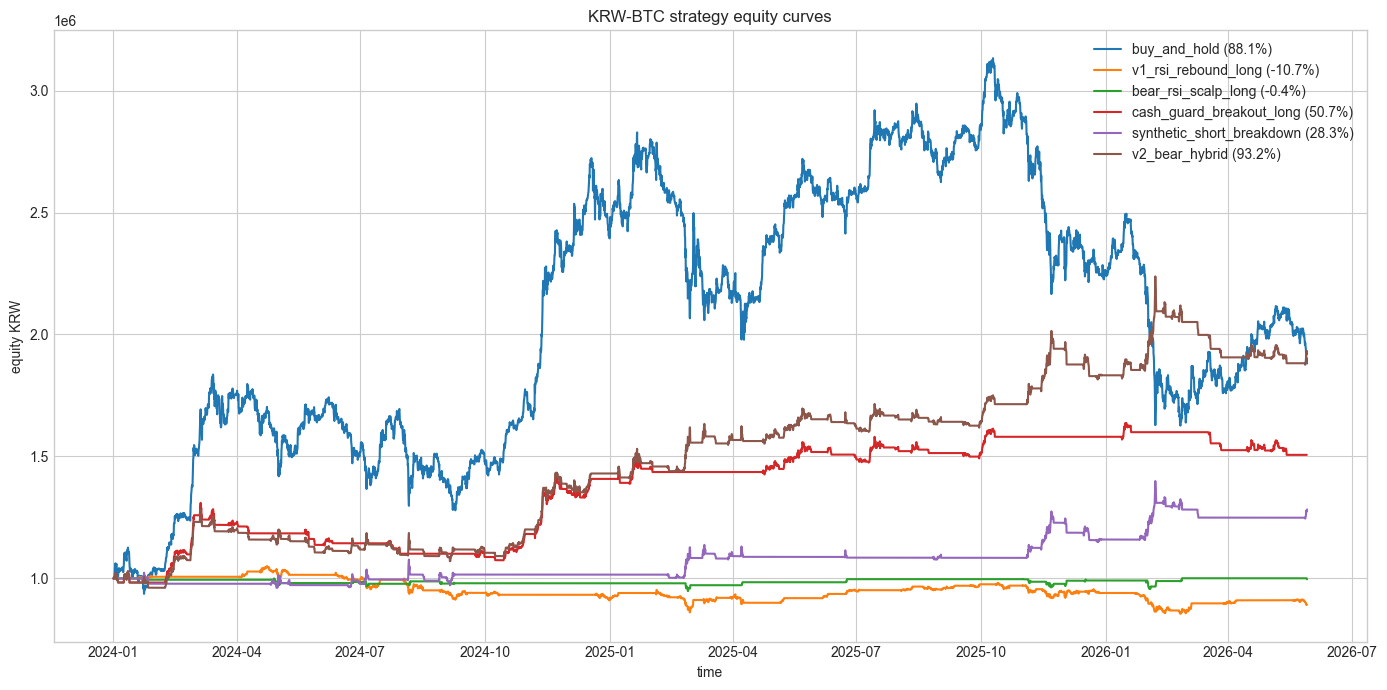

In [9]:
# 전체 연구 후보 자산곡선 비교입니다. 여기에는 숏/인버스 가상 전략도 포함됩니다.
for ticker in TICKERS:
    ticker_results = [result for result in all_results if result.ticker == ticker]
    plt.figure(figsize=(14, 7))
    for result in ticker_results:
        plt.plot(result.equity_curve.index, result.equity_curve.values, label=f"{result.strategy} ({result.total_return_pct:.1f}%)")
    plt.title(f"{ticker} all research strategy equity curves")
    plt.xlabel("time")
    plt.ylabel("equity KRW")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


In [10]:
# 최근 하락장 구간과 현물 기준 최선 전략의 진입 로그를 함께 확인합니다.
SPOT_LOG_STRATEGIES = [
    "cash_guard_breakout_long",
    "spot_cash_guard_optimized",
    "spot_cash_guard_robust",
    "spot_defensive_combo",
    "bear_spot_quick_rebound",
    "panic_reversal_long",
    "bear_rsi_scalp_long",
]
for ticker in TICKERS:
    df = prepared_data[ticker]
    bear_ratio = df["bear_regime"].mean() * 100
    print(f"{ticker} bear_regime ratio: {bear_ratio:.1f}%")

    spot_ranked = ranked[(ranked["ticker"] == ticker) & (ranked["strategy"].isin(SPOT_LOG_STRATEGIES))]
    if spot_ranked.empty:
        print("현물 전략 결과가 없습니다.")
        continue
    best_strategy_name = spot_ranked.iloc[0]["strategy"]
    best_result = next(result for result in all_results if result.ticker == ticker and result.strategy == best_strategy_name)
    print(f"best spot-only by score: {best_strategy_name}")
    display(best_result.trades.tail(20) if not best_result.trades.empty else pd.DataFrame())


KRW-BTC bear_regime ratio: 35.8%
best by score: v2_bear_hybrid


,ticker,strategy,side,entry_time,exit_time,entry_price,exit_price,return_pct,equity_after,bars_held
93,KRW-BTC,v2_bear_hybrid,short,2025-12-24 17:00:00,2025-12-28 21:00:00,"128,662,000.00","128,185,000.00",0.19,"1,832,722.27",24
94,KRW-BTC,v2_bear_hybrid,long,2026-01-12 13:00:00,2026-01-15 01:00:00,"135,249,000.00","141,601,000.00",3.22,"1,891,661.19",14
95,KRW-BTC,v2_bear_hybrid,long,2026-01-15 01:00:00,2026-01-19 13:00:00,"141,601,000.00","137,784,000.00",-1.96,"1,854,660.71",26
96,KRW-BTC,v2_bear_hybrid,short,2026-01-25 17:00:00,2026-01-28 21:00:00,"130,684,000.00","130,402,000.00",0.08,"1,856,165.34",18
97,KRW-BTC,v2_bear_hybrid,short,2026-01-29 13:00:00,2026-02-01 05:00:00,"127,627,000.00","116,008,000.00",6.31,"1,973,213.22",15
98,KRW-BTC,v2_bear_hybrid,short,2026-02-01 05:00:00,2026-02-05 09:00:00,"116,008,000.00","107,867,000.00",4.84,"2,068,811.26",24
99,KRW-BTC,v2_bear_hybrid,short,2026-02-05 13:00:00,2026-02-06 05:00:00,"104,830,000.00","96,214,000.00",5.69,"2,186,447.83",3
100,KRW-BTC,v2_bear_hybrid,short,2026-02-06 05:00:00,2026-02-07 01:00:00,"96,214,000.00","101,854,000.00",-4.18,"2,095,154.78",4
101,KRW-BTC,v2_bear_hybrid,short,2026-02-11 17:00:00,2026-02-14 01:00:00,"99,341,000.00","100,741,000.00",-1.06,"2,073,009.12",13
102,KRW-BTC,v2_bear_hybrid,short,2026-02-18 01:00:00,2026-02-20 17:00:00,"99,999,000.00","99,977,000.00",-0.05,"2,071,877.42",15


In [ ]:
# ===== 현물 기준 후보 테이블: 숏 없이 수익/손실 컬럼 중심으로 확인합니다. =====
SPOT_TABLE_STRATEGIES = [
    "spot_cash_guard_robust",
    "spot_cash_guard_optimized",
    "bear_spot_quick_rebound",
    "spot_defensive_combo",
    "cash_guard_breakout_long",
    "panic_reversal_long",
    "bear_rsi_scalp_long",
    "v1_rsi_rebound_long",
    "buy_and_hold",
]
SPOT_TABLE_META = {
    "spot_cash_guard_robust": ("현물 메인 후보", "*/15 * * * *"),
    "spot_cash_guard_optimized": ("현물 공격형 방어 돌파 후보", "*/15 또는 */30 검토"),
    "bear_spot_quick_rebound": ("하락장 짧은 반등 보조 후보", "*/30 * * * *"),
    "spot_defensive_combo": ("현물 방어 조합 후보", "*/30 * * * *"),
    "cash_guard_breakout_long": ("기본 방어 돌파 후보", "*/15 또는 */30 검토"),
    "panic_reversal_long": ("급락 반등 연구 후보", "*/30 * * * *"),
    "bear_rsi_scalp_long": ("RSI 반등 연구 후보", "*/30 * * * *"),
    "v1_rsi_rebound_long": ("V1 RSI 현물 비교", "자동매매 후보 낮음"),
    "buy_and_hold": ("비교 기준선", "자동매매 아님"),
}

spot_rows: list[dict[str, object]] = []
for result in all_results:
    if result.strategy not in SPOT_TABLE_STRATEGIES:
        continue

    trades = result.trades.copy()
    if not trades.empty and "return_pct" in trades:
        win_trades = trades[trades["return_pct"] > 0]
        loss_trades = trades[trades["return_pct"] <= 0]
        best_trade_pct = float(trades["return_pct"].max())
        worst_trade_pct = float(trades["return_pct"].min())
        avg_win_pct = float(win_trades["return_pct"].mean()) if not win_trades.empty else 0.0
        avg_loss_pct = float(loss_trades["return_pct"].mean()) if not loss_trades.empty else 0.0
        win_count = int(len(win_trades))
        loss_count = int(len(loss_trades))
    else:
        best_trade_pct = 0.0
        worst_trade_pct = 0.0
        avg_win_pct = 0.0
        avg_loss_pct = 0.0
        win_count = 0
        loss_count = 0

    role, recommended_cron = SPOT_TABLE_META[result.strategy]
    initial_capital = float(INITIAL_CAPITAL)
    net_profit_krw = result.final_equity - initial_capital
    spot_rows.append(
        {
            "ticker": result.ticker,
            "strategy": result.strategy,
            "role": role,
            "recommended_cron": recommended_cron,
            "profit_status": "수익" if result.total_return_pct > 0 else ("손실" if result.total_return_pct < 0 else "보합"),
            "initial_capital": initial_capital,
            "final_equity": result.final_equity,
            "net_profit_krw": net_profit_krw,
            "total_return_pct": result.total_return_pct,
            "max_drawdown_pct": result.max_drawdown_pct,
            "trade_count": result.trade_count,
            "win_count": win_count,
            "loss_count": loss_count,
            "win_rate_pct": result.win_rate_pct,
            "profit_factor": result.profit_factor,
            "best_trade_pct": best_trade_pct,
            "worst_trade_pct": worst_trade_pct,
            "avg_win_trade_pct": avg_win_pct,
            "avg_loss_trade_pct": avg_loss_pct,
            "exposure_pct": result.exposure_pct,
        }
    )

spot_candidate_table = pd.DataFrame(spot_rows)
spot_candidate_table = spot_candidate_table.sort_values(
    ["ticker", "total_return_pct", "max_drawdown_pct"],
    ascending=[True, False, False],
)

# 보기 좋게 반올림한 표시용 표입니다. 원본 값이 필요하면 spot_candidate_table을 직접 확인합니다.
spot_candidate_table_display = spot_candidate_table.copy()
for column in [
    "initial_capital",
    "final_equity",
    "net_profit_krw",
    "total_return_pct",
    "max_drawdown_pct",
    "win_rate_pct",
    "profit_factor",
    "best_trade_pct",
    "worst_trade_pct",
    "avg_win_trade_pct",
    "avg_loss_trade_pct",
    "exposure_pct",
]:
    spot_candidate_table_display[column] = spot_candidate_table_display[column].round(2)

display(spot_candidate_table_display)


## 운영 추천

현재 KRW-BTC 2024년 이후 백테스트 기준 추천은 다음 순서입니다.

1. 숏 실행 수단이 있으면 `v2_bear_hybrid_optimized` + `minute240` + `*/30 * * * *`를 우선 후보로 봅니다.
2. 업비트 현물만 사용하면 `spot_cash_guard_optimized` + `minute60` + `*/15 * * * *`가 현재 가장 나은 현물 후보입니다.
3. `minute15` 단타는 거래 빈도는 높일 수 있지만, 현재 후보군에서는 60분/240분 전략보다 성과가 약했습니다.
4. 크론은 캔들보다 자주 돌리되, 실거래 봇에서는 마지막 처리 캔들 시간을 파일/DB에 저장해 같은 캔들 중복 주문을 막아야 합니다.
5. 수수료는 `FEE_RATE = 0.0005`로 반영했고, `stress_summary`에서 왕복 추가 비용 0.1~0.4%를 더해 슬리피지까지 확인합니다.

업비트 현물은 숏을 지원하지 않으므로, 하락 자체에서 수익을 내는 전략은 선물/마진/인버스 실행 환경에서만 실거래로 연결할 수 있습니다.

노트북을 실행한 뒤에는 `최종 후보 선정표` 셀을 보고 실제 운영 후보를 고릅니다.


## 판단 기준

- 업비트 현물만 운용한다면 숏 전략은 실제 주문으로 바로 연결하지 말고, `bear_rsi_scalp_long` 또는 `cash_guard_breakout_long`처럼 현금 비중을 크게 두는 전략부터 검토합니다.
- 하락장에서 적극적으로 수익을 내려면 현물 롱만으로는 구조적으로 한계가 큽니다. `synthetic_short_breakdown` 또는 `v2_bear_hybrid`가 우수하게 나오면 선물/마진/인버스 상품을 별도 거래소에서 쓸 때의 후보로 봐야 합니다.
- `score`는 자동 추천용 임시 점수입니다. 실전 적용 전에는 종목 수 확대, 슬리피지, 최소 주문 금액, 펀딩비, 동시 포지션 제한, API 장애 상황을 추가해야 합니다.

- 최적화 셀은 전체 기간 성과 기준의 과최적화 위험이 있습니다. 상위 후보는 반드시 별도 기간 분리, 워크포워드, 다종목 검증으로 다시 확인해야 합니다.
- 워크포워드 셀에서 선택된 후보가 테스트 구간에서도 우위인지 확인한 뒤에만 실전 후보로 올립니다.
- 현물만 사용할 경우에는 `spot_optimization_summary`의 상위 후보와 `cash_guard_breakout_long`을 우선 비교합니다.
- `stress_summary`에서 비용을 올렸을 때 수익률이 급격히 무너지면 실전 자동매매 후보에서 제외합니다.
- 크론탭 실행은 추천 분봉보다 짧은 간격으로 돌리되, 봇 내부에서 마지막으로 처리한 캔들 시간을 저장해 같은 캔들 중복 주문을 막아야 합니다.
- 기본 추천은 4시간봉 전략이면 `*/30 * * * *`, 60분봉 전략이면 `*/15 * * * *`, 15분봉 단타면 `*/5 * * * *`입니다.
- 현물 최적화 후보는 `spot_walk_forward_summary`에서 기간 분리 성과를 확인합니다.
